In [1]:
import numpy as np
from game.game import Game

In [2]:
from game.enums import BoardType, Tribes, ActionTypes, UnitType, UnitState

import matplotlib.pyplot as plt

In [3]:
N_TILES = 100
N_UNIT_TYPES = len(UnitType)

In [4]:
board_config = {
        "board_size" : (10,10),
        "board_type" : BoardType.Dummy,
        "n_players" : 2,
}
player_tribes = [Tribes.Omaji, Tribes.Imperius]

game1 = Game(board_config, player_tribes)
game1.reset_game()
game1.player_go_id = 1

print(game1.players[0].cities_under_control[0].unit, game1.players[1].cities_under_control[0].unit, "\n")

all_tile_indcs = game1.game_board.int_to_tup.keys()

game1.game_board.create_board_graph_from_board_state(all_tile_indcs)
game1.players[1].reset(game1.game_board)
game1.players[0].reset(game1.game_board)

warr1 = game1.players[1].units_under_control[0]
warr2 = game1.players[0].units_under_control[0]
warr1.set_ready()
warr2.set_ready()


print(warr1)

possible_targets_dict_w_path = game1.calc_movement_target_and_shortest_path(warr1)
target_tile_id = [game1.game_board.tup_to_int[x] for x in possible_targets_dict_w_path.keys()][-1]
path_in_ids = [game1.game_board.tup_to_int[x] for x in list(possible_targets_dict_w_path.values())[-1]]

action1 = {
    "type" : ActionTypes.MoveUnit,
    "unit": 0,
    "target_id": target_tile_id,
    "path": path_in_ids
}
print(action1)
game1.apply_action(action1)

print(warr1)

action2 = {
    "type" : ActionTypes.Attack,
    "unit" : 0,
    "o_unit_index" : 0
}

print(action2)
game1.apply_action(action2)
print(warr1, warr2, "\n\n")

game1.player_go_id = 0

action3 = {
    "type" : ActionTypes.Attack,
    "unit" : 0,
    "o_unit_index" : 0
}

print(action3)
game1.apply_action(action3)
print(game1.players[0].units_under_control, game1.players[1].units_under_control)

game1.player_go_id = 1

action4 = {
    "type" : ActionTypes.CreateUnit,
    "city" : 0,
    "unit_type" : UnitType.Warrior
}

print(action4)

game1.apply_action(action4)

print(game1.players[0].cities_under_control[0].unit, game1.players[1].cities_under_control[0].unit)
print(game1.players[1].units_under_control)


action5 = {
    "type" : ActionTypes.CaptureCity,
    "unit" : 0,
}





Warrior (10/10) in state idle Warrior (10/10) in state idle 

Warrior (10/10) in state ready
{'type': <ActionTypes.MoveUnit: 0>, 'unit': 0, 'target_id': 49, 'path': [38, 49]}
Warrior (10/10) in state idle
{'type': <ActionTypes.Attack: 1>, 'unit': 0, 'o_unit_index': 0}
Warrior (5/10) in state idle Warrior (5/10) in state ready 


{'type': <ActionTypes.Attack: 1>, 'unit': 0, 'o_unit_index': 0}
[<game.components.units.Warrior object at 0x000001DD570D4CD0>] []
{'type': <ActionTypes.CreateUnit: 2>, 'city': 0, 'unit_type': <UnitType.Warrior: 0>}
None Warrior (10/10) in state idle


In [5]:
game1.game_board.create_board_graph_from_board_state(np.arange(100))
current_board_graph = game1.game_board.board_graph.reshape((*game1.game_board.board_size, -1))

0 1 2	3  4        5 6 7 8 9	0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5
1 0 0	0  1		0 0 0 0 0 	0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
		P1 P2		v P1--P2--	P1--------------P2-------------
field	player		city 		W-------R-------W-------R------
type	control		feats		i r e h i r e h i r e h i r e h
								Units

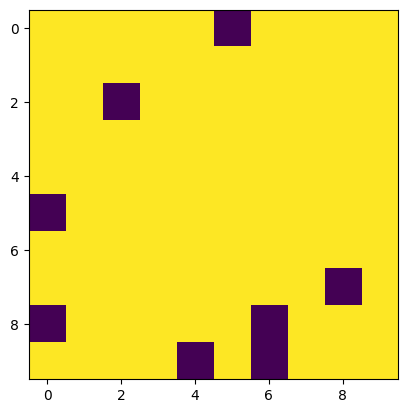

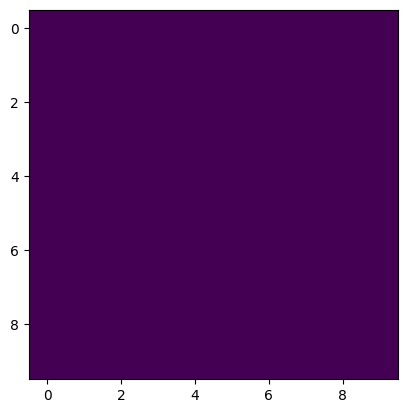

In [6]:
plt.imshow(current_board_graph[...,0])
plt.show()
plt.imshow(current_board_graph[...,11])

In [7]:
def _get_valid_move_locations(game, unit, greedy_search=False):

    unit_loc_key = game.game_board.int_to_tup[unit.tile.id]
    if greedy_search:
        can_reach = game.calc_movement_target_and_shortest_path(unit, greedy_search=greedy_search)
        return can_reach
        
    possible_targets_dict_w_path = game.calc_movement_target_and_shortest_path(unit)
    possible_targets_dict_w_path.pop(unit_loc_key)
    
    target_tile_ids = [game.game_board.tup_to_int[x] for x in possible_targets_dict_w_path.keys()]
    #paths_in_ids = [game.game_board.tup_to_int[x] for x in list(possible_targets_dict_w_path.values())]

    return target_tile_ids

In [8]:
game1.player_go_id = 0

print(warr2)

Warrior (5/10) in state idle


In [9]:
warr2.tile.id

49

In [10]:
np.nonzero(game1.players[0].partial_graph)

(array([ 5,  6,  7,  8,  9,  9, 15, 16, 17, 17, 18, 19, 25, 26, 27, 28, 29,
        35, 35, 36, 37, 38, 38, 39, 48, 49, 49, 58, 59]),
 array([ 1,  0,  0,  0,  0,  5,  0,  0,  0,  6,  0,  0,  0,  0,  0,  0,  0,
         0,  5,  0,  0,  0,  8,  0,  0,  0, 10,  0,  0]))

In [11]:
_get_valid_move_locations(game1, warr2)

[38, 39, 48, 59, 58]

In [12]:


def get_action_mask(game):
    """
    Another big one; gets all possible actions and subactions at any time
    """
    player = game.players[game.player_go_id]
    opponent = game.players[(game.player_go_id + 1) % 2]
    num_actions = len(ActionTypes)
    num_units_player = len(player.units_under_control)
    num_units_opponent = len(opponent.units_under_control)
    num_cities_player = len(player.cities_under_control)

    valid_actions = [ ## the order is hard-coded...
        np.zeros((num_actions,)),
        np.zeros((num_units_player, N_TILES)), #move unit
        np.zeros((num_units_player, num_units_opponent)), # attack enemy unit
        np.zeros((num_cities_player, N_UNIT_TYPES)), #create unit
        np.zeros((num_units_player,)), # capture village/ seige city
        
    ]

    # move unit
    unit_can_move = np.zeros((num_units_player,))
    for unit_id, unit in enumerate(player.units_under_control):
        can_move_bool = (unit.turn_state in (UnitState.ready, UnitState.escaping) and _get_valid_move_locations(game, unit, greedy_search=True))
        if can_move_bool:
            unit_can_move[unit_id] = 1

    if sum(unit_can_move) > 0: # there is a unit that can move
        valid_actions[0][ActionTypes.MoveUnit] = 1.0
        for unit_id, unit_valid in enumerate(unit_can_move):
            if unit_valid == 1: # the specific unit can move; set the rows with possible targets
                target_tile_ids = _get_valid_move_locations(game, player.units_under_control[unit_id])
                valid_actions[1][unit_id][target_tile_ids] = 1.0 # smart indexing

    # attack
    ## PART 1: Which units are eligible to attack (decide, wether action is possible)
    unit_can_hit = np.zeros((num_units_player,))
    for unit_id, unit in enumerate(player.units_under_control):
        surrounding_unit_player_ids = [game.game_board.board[id].unit.player_id for id in game.tiles_in_range(unit.tile.id, unit.attack_range) \
                                       if game.game_board.board[id].unit != None]
    
        can_hit_bool = (unit.turn_state in (UnitState.ready, UnitState.can_hit) and opponent.player_id in surrounding_unit_player_ids)    
        if can_hit_bool:
            unit_can_hit[unit_id] = 1
    
    if num_units_player == 0 or num_units_opponent == 0:
        unit_can_hit = np.zeros(1) # if there is no defender to attack; skip this action

    ## PART 2: given a unit can attack, which unit can attack which defenders?
    if sum(unit_can_hit) > 0:
        valid_actions[0][ActionTypes.Attack] = 1.0
        for attacker_id, can_hit in enumerate(unit_can_hit):
            if can_hit == 1: # the specific unit can hit
                unit = player.units_under_control[attacker_id]
                reachable_tiles = game.tiles_in_range(unit.tile.id, unit.attack_range) # where can the specifics units attack reach
                for defender_id, defender in enumerate(opponent.units_under_control):
                    if defender.tile.id in reachable_tiles:
                        valid_actions[2][attacker_id][defender_id] = 1.0 # means: defender is in range of attacker

    # create unit
    can_create_unit = np.array([1 if ((city.current_n_units < city.max_unit_cap) and city.unit == None) \
                                else 0 for city in player.cities_under_control])
    if sum(can_create_unit) > 0: #TODO: include unit cost here too
        valid_actions[0][ActionTypes.CreateUnit] = 1.0
        for city_id, city_valid in enumerate(can_create_unit):
            if city_valid == 1: #the city can hold more units
                valid_actions[3][city_id] = np.ones((N_UNIT_TYPES,)) ## this will be dependent on current stars
            
    # capture city
    can_capture_city = np.zeros((num_units_player,))
    for unit_id, unit in enumerate(player.units_under_control):
        city = unit.tile.city
        city_bool = (city != None and (city.player_id != player.player_id or city.player_id == None) and unit.turn_state == UnitState.ready)
        if city_bool:
            can_capture_city[unit_id] = 1
            
    if sum(can_capture_city) > 0:
        valid_actions[0][ActionTypes.CaptureCity] = 1.0
        for unit_id, unit_valid in enumerate(can_capture_city):
            if unit_valid == 1:
                valid_actions[4][unit_id] = 1.0

    # end turn
    if sum(valid_actions[0]) == 0: # if there is nothing more to do 
        valid_actions[0][ActionTypes.EndTurn] = 1.0
        
    
    return valid_actions
    

In [13]:
print(game1.players[0].units_under_control[0])

Warrior (5/10) in state idle


In [14]:
game1.player_go_id = 0
game1.players[0].units_under_control[0].set_ready()
#game1.players[0].units_under_control[0].turn_state = UnitState.can_hit

action_mask1 = get_action_mask(game1)
action_mask1

[array([1., 1., 1., 0., 0.]),
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]),
 array([[1.]]),
 array([[1., 1.]]),
 array([0.])]

In [15]:
def _translate_action(game, action):
    """
    action is a simple list of integer indices, specific to each possible action type, for example:
    action = [0, 2, 55] --> Move (0) unit (2) to tile (55)
    action = [2, 0, 1] ---> Create (2) in city (0) a rider (1)
    action = [4] ---> current player ends his turn
    """
    player = game.players[game.player_go_id]
    translated_action = {}
    action_type = ActionTypes(action[0])
    translated_action["type"] = action_type

    if action_type == ActionTypes.MoveUnit:
        translated_action["unit"] = action[1]
        translated_action["target_id"] = action[2]
        
        ## i have to recalculate the path...
        unit = player.units_under_control[action[1]]
        path_in_ids = [game.game_board.tup_to_int[x] for x in game.calc_movement_target_and_shortest_path(unit, target_tile=action[2])]
        translated_action["path"] = path_in_ids

    elif action_type == ActionTypes.Attack:
        translated_action["unit"] = action[1]
        translated_action["o_unit_index"] = action[2]

    elif action_type == ActionTypes.CreateUnit:
        translated_action["city"] = action[1]
        translated_action["unit_type"] = UnitType(action[2])

    elif action_type == ActionTypes.CaptureCity:
        translated_action["unit"] = action[1]

    elif action_type == ActionTypes.EndTurn:
        pass # do nothing here atm

    
    return translated_action

    

In [16]:
def select_random_matrix_element(mat):
    nonzero_rows = np.where(mat.any(axis=1))[0]
    row_idx = np.random.choice(nonzero_rows)
    col_idx = np.random.choice(np.flatnonzero(mat[row_idx]))
    return row_idx, col_idx

def select_random_array_element(arr):
    return np.random.choice(np.flatnonzero(arr))

def _create_random_action_from_action_mask(action_mask):
    
    action = []
    choose_action_type = np.random.choice(np.flatnonzero(action_mask[0]))

    if ActionTypes(choose_action_type) == ActionTypes.MoveUnit:
        action.append(ActionTypes.MoveUnit.value)
        unit_id, loc_id = select_random_matrix_element(action_mask[1])
        action.append(unit_id)
        action.append(loc_id)

    elif ActionTypes(choose_action_type) == ActionTypes.Attack:
        action.append(ActionTypes.Attack.value)
        unit_id, defender_id = select_random_matrix_element(action_mask[2])
        action.append(unit_id)
        action.append(defender_id)

    elif ActionTypes(choose_action_type) == ActionTypes.CreateUnit:
        action.append(ActionTypes.CreateUnit.value)
        city_id, unit_type = select_random_matrix_element(action_mask[3])
        action.append(city_id)
        action.append(unit_type)

    elif ActionTypes(choose_action_type) == ActionTypes.CaptureCity:
        action.append(ActionTypes.CaptureCity.value)
        action.append(select_random_array_element(action_mask[4])) 

    elif ActionTypes(choose_action_type) == ActionTypes.EndTurn:
        action.append(ActionTypes.EndTurn.value)

    return action
    

In [17]:
action = _create_random_action_from_action_mask(action_mask1)
print(action)
action_dict = _translate_action(game1, action)
print(action_dict)
game1.apply_action(action_dict)

[1, np.int64(0), np.int64(0)]
{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(0), 'o_unit_index': np.int64(0)}


1

# Set up a random game and let run:

In [18]:
from matplotlib.patches import Circle, Rectangle, Polygon, FancyBboxPatch
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches

def render_board(state_graph, Nx, Ny, figsize=(4, 4)):
    """
    Render the board game state.
    
    Parameters:
    state_graph: numpy array of shape (Nx * Ny, 26)
    Nx: number of tiles in x direction
    Ny: number of tiles in y direction
    figsize: figure size tuple
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    state_grid = state_graph.reshape(Nx, Ny, 26)
    
    for i in range(Nx):
        for j in range(Ny):
            tile = state_grid[i, j]
            x, y = j, Nx - 1 - i
            
            if tile[2] > 0:
                rect = Rectangle((x, y), 1, 1, facecolor='#00008B', edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
            elif tile[1] > 0:
                rect = Rectangle((x, y), 1, 1, facecolor='#4169E1', edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
            elif tile[0] > 0:
                rect = Rectangle((x, y), 1, 1, facecolor='#90EE90', edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
            else:
                rect = Rectangle((x, y), 1, 1, facecolor='white', edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
            
            if tile[3] > 0:
                shine = Rectangle((x, y), 1, 1, facecolor='#ADD8E6', alpha=0.4, edgecolor='none')
                ax.add_patch(shine)
            
            if tile[4] > 0:
                shine = Rectangle((x, y), 1, 1, facecolor='#FFB6C1', alpha=0.4, edgecolor='none')
                ax.add_patch(shine)
            
            if tile[5] > 0:
                circle = Circle((x + 0.5, y + 0.5), 0.15, facecolor='#8B4513', edgecolor='black', linewidth=1)
                ax.add_patch(circle)
            
            if tile[6] > 0:
                circle = Circle((x + 0.5, y + 0.5), 0.15, facecolor='blue', edgecolor='black', linewidth=1)
                ax.add_patch(circle)
            
            if tile[8] > 0:
                circle = Circle((x + 0.5, y + 0.5), 0.15, facecolor='red', edgecolor='black', linewidth=1)
                ax.add_patch(circle)
    
    for i in range(Nx):
        for j in range(Ny):
            tile = state_grid[i, j]
            x, y = j, Nx - 1 - i
            
            if np.any(tile[10:14] > 0):
                pawn_points = np.array([
                    [x + 0.5, y + 0.7],
                    [x + 0.4, y + 0.3],
                    [x + 0.6, y + 0.3]
                ])
                pawn = Polygon(pawn_points, facecolor='blue', edgecolor='darkblue', linewidth=1.5)
                ax.add_patch(pawn)
                head = Circle((x + 0.5, y + 0.75), 0.08, facecolor='blue', edgecolor='darkblue', linewidth=1.5)
                ax.add_patch(head)
            
            if np.any(tile[14:18] > 0):
                body = Rectangle((x + 0.35, y + 0.35), 0.3, 0.25, facecolor='blue', edgecolor='darkblue', linewidth=1.5)
                ax.add_patch(body)
                head_points = np.array([
                    [x + 0.5, y + 0.75],
                    [x + 0.4, y + 0.6],
                    [x + 0.6, y + 0.6]
                ])
                head = Polygon(head_points, facecolor='blue', edgecolor='darkblue', linewidth=1.5)
                ax.add_patch(head)
                ear = Circle((x + 0.65, y + 0.7), 0.06, facecolor='blue', edgecolor='darkblue', linewidth=1.5)
                ax.add_patch(ear)
            
            if np.any(tile[18:22] > 0):
                pawn_points = np.array([
                    [x + 0.5, y + 0.7],
                    [x + 0.4, y + 0.3],
                    [x + 0.6, y + 0.3]
                ])
                pawn = Polygon(pawn_points, facecolor='red', edgecolor='darkred', linewidth=1.5)
                ax.add_patch(pawn)
                head = Circle((x + 0.5, y + 0.75), 0.08, facecolor='red', edgecolor='darkred', linewidth=1.5)
                ax.add_patch(head)
            
            if np.any(tile[22:26] > 0):
                body = Rectangle((x + 0.35, y + 0.35), 0.3, 0.25, facecolor='red', edgecolor='darkred', linewidth=1.5)
                ax.add_patch(body)
                head_points = np.array([
                    [x + 0.5, y + 0.75],
                    [x + 0.4, y + 0.6],
                    [x + 0.6, y + 0.6]
                ])
                head = Polygon(head_points, facecolor='red', edgecolor='darkred', linewidth=1.5)
                ax.add_patch(head)
                ear = Circle((x + 0.65, y + 0.7), 0.06, facecolor='red', edgecolor='darkred', linewidth=1.5)
                ax.add_patch(ear)
    
    ax.set_xlim(0, Ny)
    ax.set_ylim(0, Nx)
    ax.set_aspect('equal')
    ax.set_xticks(range(Ny + 1))
    ax.set_yticks(range(Nx + 1))
    ax.grid(True, alpha=0.3)
    ax.set_title('Board Game State', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [19]:
board_config = {
        "board_size" : (10,10),
        "board_type" : BoardType.Dummy,
        "n_players" : 2,
}
N_TILES = board_config["board_size"][0] * board_config["board_size"][1]

player_tribes = [Tribes.Omaji, Tribes.Imperius]

game2 = Game(board_config, player_tribes)
game2.reset_game()

for i in range(1000):

    #for unit in game2.players[game2.player_go_id].units_under_control:
    #    print(unit, "    ", unit.tile.id)

    #render_board(game2.game_board.board_graph, board_config["board_size"][0], board_config["board_size"][0])
    
    action_mask = get_action_mask(game2)

    action = _create_random_action_from_action_mask(action_mask)

    action_dict = _translate_action(game2, action)

    print(action_dict)

    game2.apply_action(action_dict)
    

{'type': <ActionTypes.EndTurn: 4>}
{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(88), 'path': [99, 88]}
{'type': <ActionTypes.CreateUnit: 2>, 'city': np.int64(0), 'unit_type': <UnitType.Rider: 1>}
{'type': <ActionTypes.EndTurn: 4>}
{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(34), 'path': [44, 34]}
{'type': <ActionTypes.CreateUnit: 2>, 'city': np.int64(0), 'unit_type': <UnitType.Rider: 1>}
{'type': <ActionTypes.EndTurn: 4>}
{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(87), 'path': [99, 98, 87]}
{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(79), 'path': [87, 78, 79]}
{'type': <ActionTypes.CreateUnit: 2>, 'city': np.int64(0), 'unit_type': <UnitType.Rider: 1>}
{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(77), 'path': [88, 77]}
{'type': <ActionTypes.EndTurn: 4>}
{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'targe

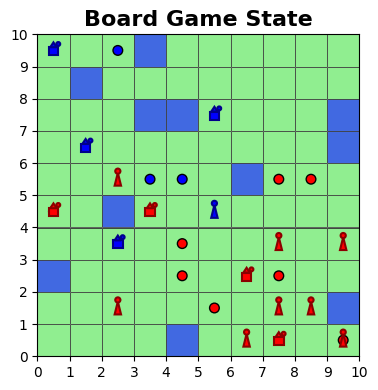

{'type': <ActionTypes.CreateUnit: 2>, 'city': np.int64(0), 'unit_type': <UnitType.Warrior: 0>}


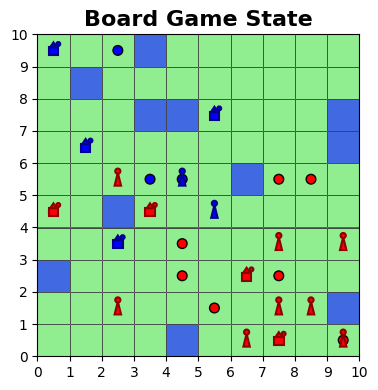

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(3), 'target_id': np.int64(20), 'path': [0, 10, 20]}


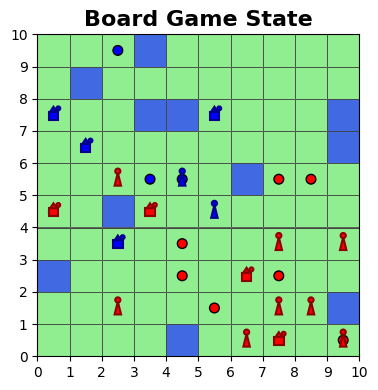

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(14), 'path': [25, 14]}


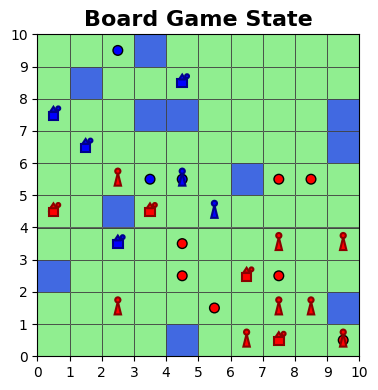

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(3), 'target_id': np.int64(12), 'path': [20, 21, 12]}


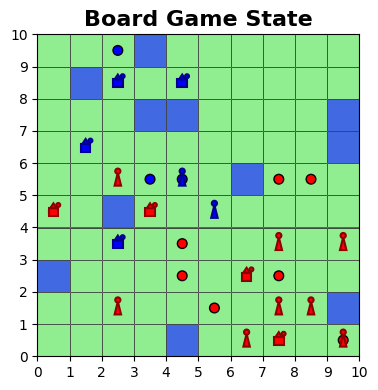

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(4), 'o_unit_index': np.int64(4)}


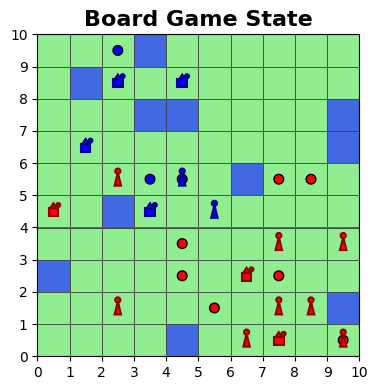

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(4), 'target_id': np.int64(73), 'path': [53, 63, 73]}


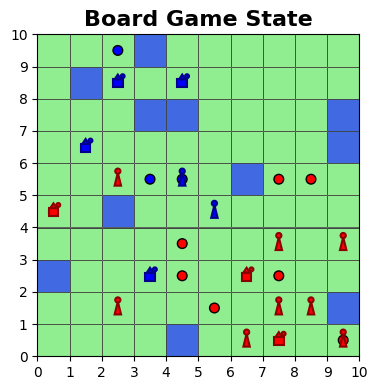

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(0), 'o_unit_index': np.int64(3)}


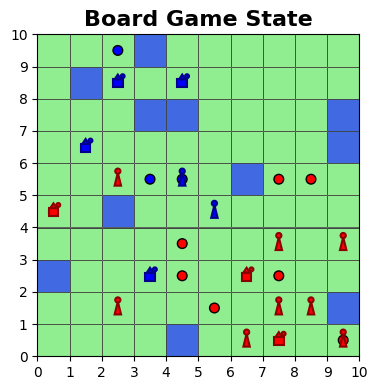

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(12), 'path': [14, 13, 12]}


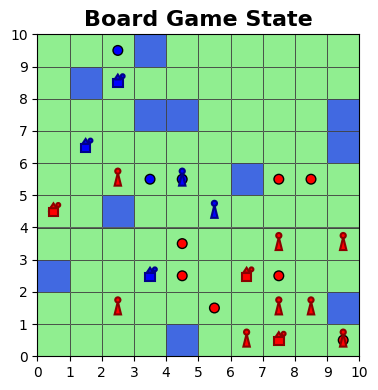

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(2), 'target_id': np.int64(66), 'path': [55, 66]}


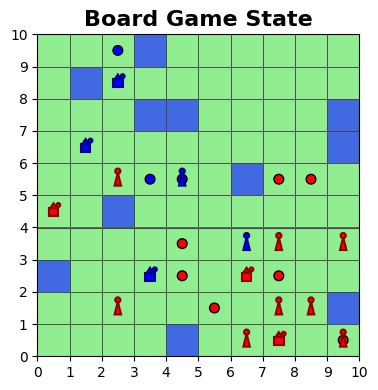

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(2), 'o_unit_index': np.int64(7)}


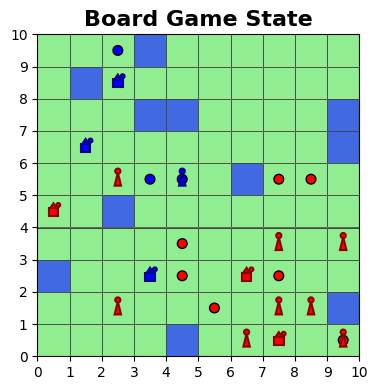

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(50), 'path': [31, 41, 50]}


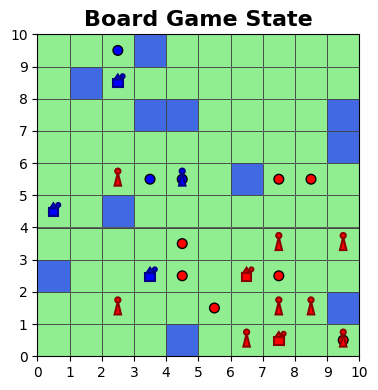

{'type': <ActionTypes.EndTurn: 4>}


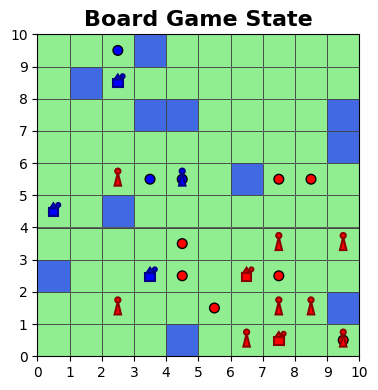

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(4), 'o_unit_index': np.int64(0)}


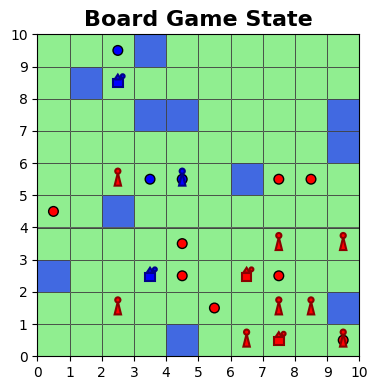

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(0), 'o_unit_index': np.int64(3)}


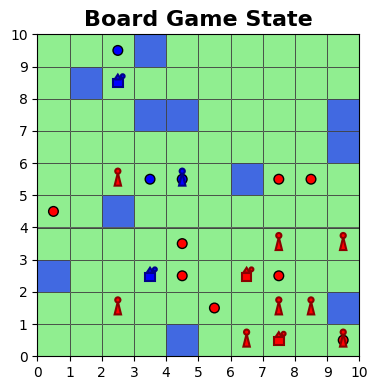

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(4), 'target_id': np.int64(77), 'path': [97, 86, 77]}


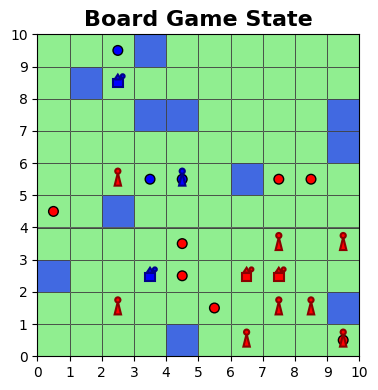

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(86), 'path': [96, 86]}


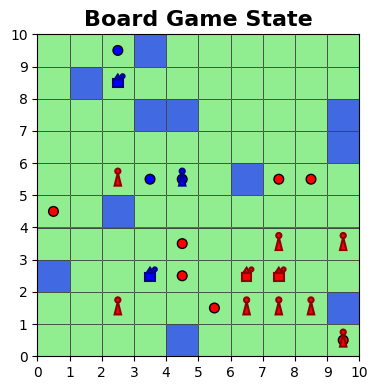

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(2), 'target_id': np.int64(79), 'path': [69, 79]}


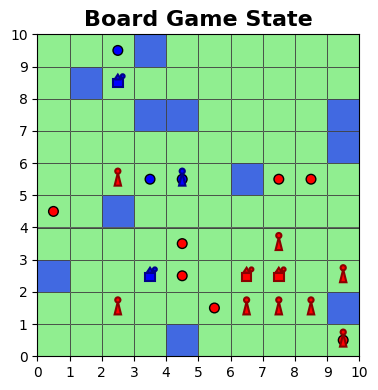

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(5), 'o_unit_index': np.int64(4)}


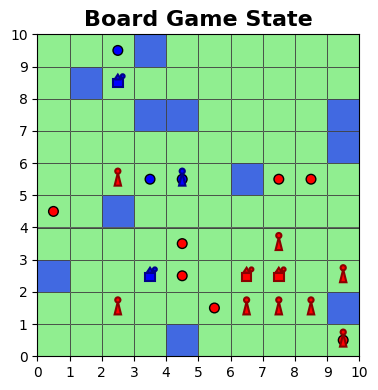

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(5), 'o_unit_index': np.int64(4)}


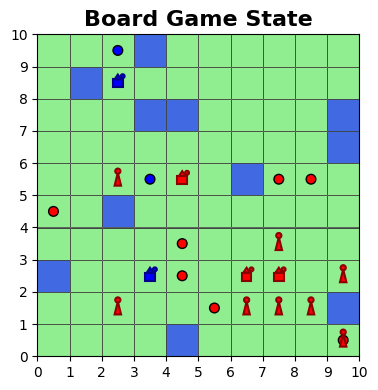

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(5), 'target_id': np.int64(32), 'path': [44, 33, 32]}


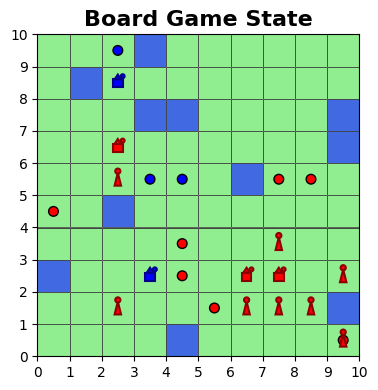

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(10), 'target_id': np.int64(98), 'path': [99, 98]}


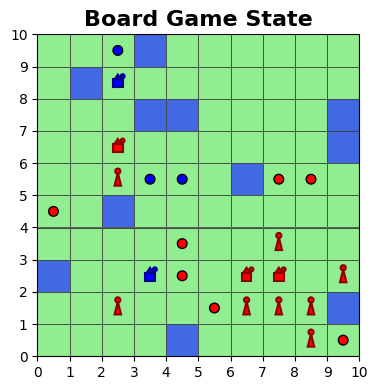

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(9), 'target_id': np.int64(79), 'path': [88, 79]}


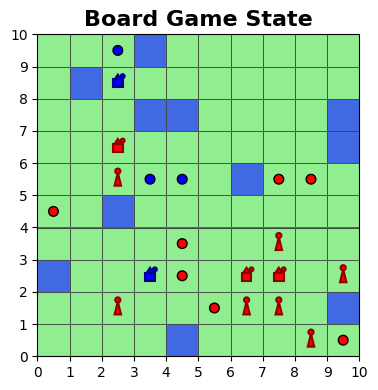

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(0), 'o_unit_index': np.int64(3)}


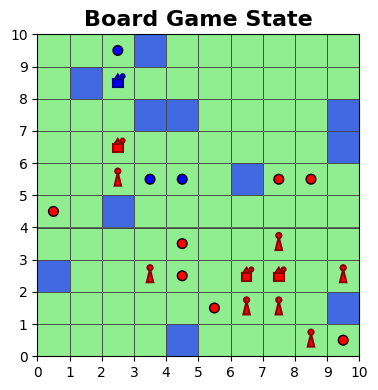

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(4), 'target_id': np.int64(66), 'path': [77, 66]}


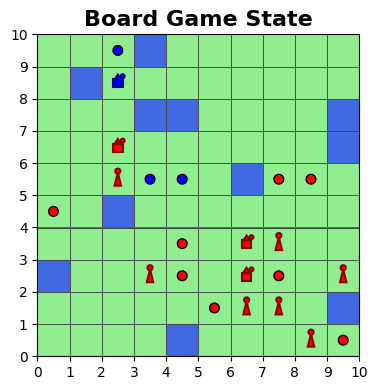

{'type': <ActionTypes.CreateUnit: 2>, 'city': np.int64(0), 'unit_type': <UnitType.Warrior: 0>}


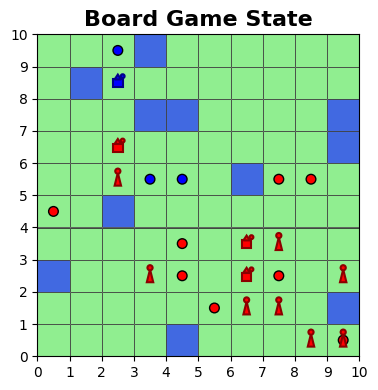

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(6), 'target_id': np.int64(66), 'path': [67, 66]}


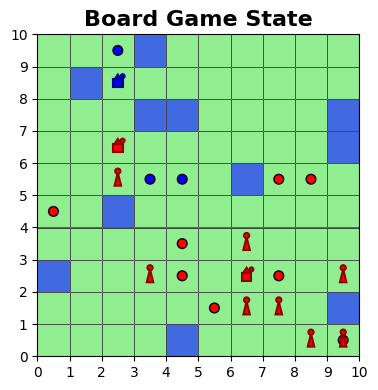

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(7), 'target_id': np.int64(78), 'path': [87, 78]}


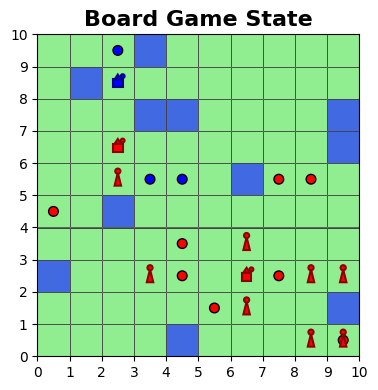

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(8), 'target_id': np.int64(56), 'path': [76, 65, 56]}


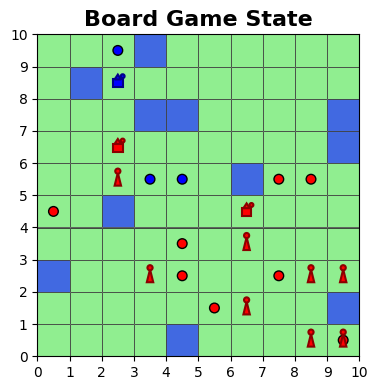

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(8), 'target_id': np.int64(54), 'path': [56, 45, 54]}


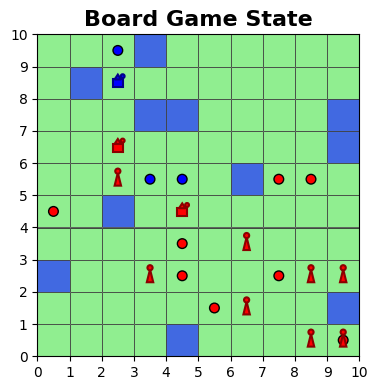

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(3), 'target_id': np.int64(31), 'path': [42, 31]}


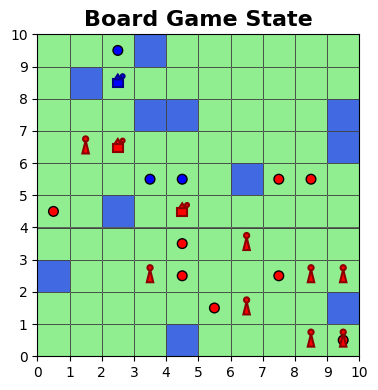

{'type': <ActionTypes.EndTurn: 4>}


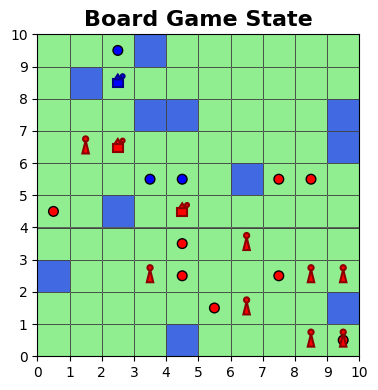

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(31), 'path': [50, 40, 31]}


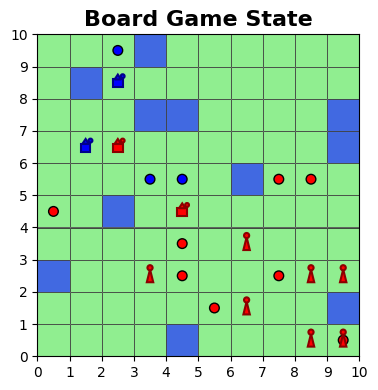

{'type': <ActionTypes.CreateUnit: 2>, 'city': np.int64(0), 'unit_type': <UnitType.Rider: 1>}


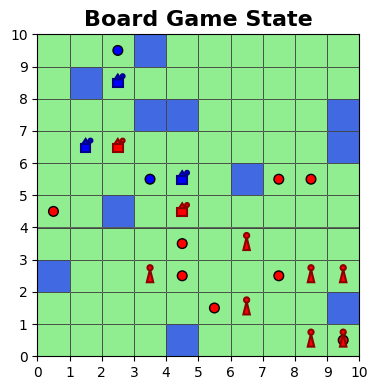

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(0), 'o_unit_index': np.int64(3)}


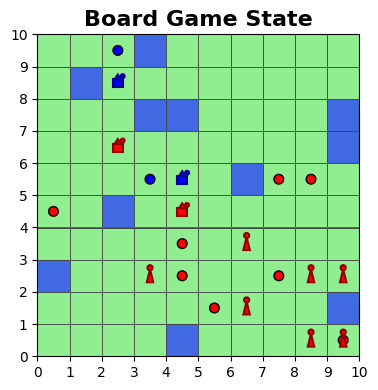

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(1), 'path': [12, 1]}


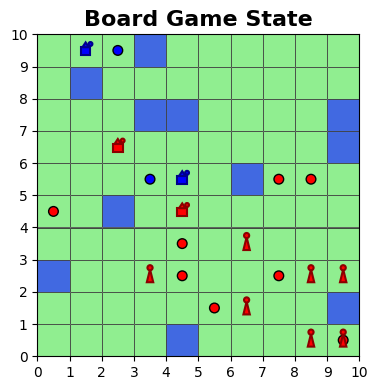

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(1), 'target_id': np.int64(2), 'path': [1, 2]}


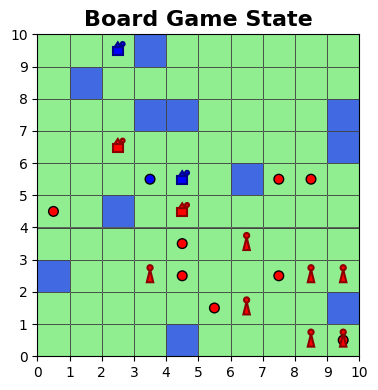

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(14), 'path': [12, 13, 14]}


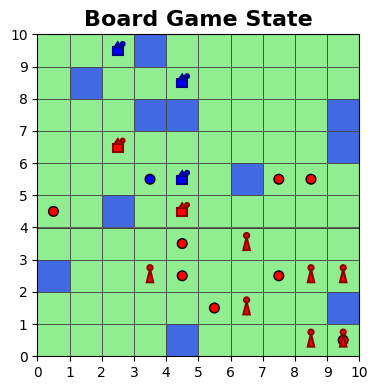

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(0), 'target_id': np.int64(12), 'path': [14, 13, 12]}


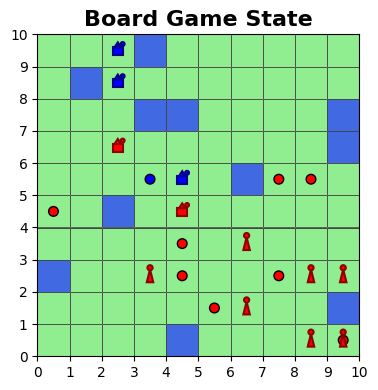

{'type': <ActionTypes.EndTurn: 4>}


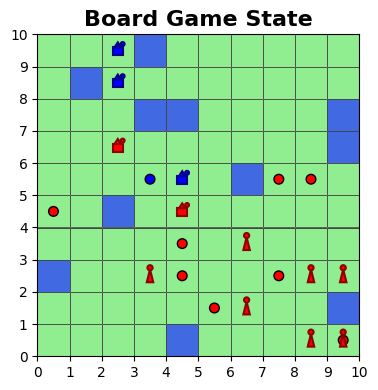

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(8), 'o_unit_index': np.int64(2)}


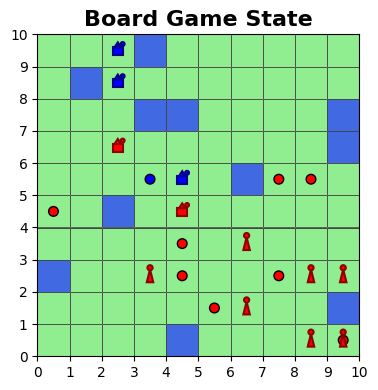

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(4), 'target_id': np.int64(45), 'path': [66, 55, 45]}


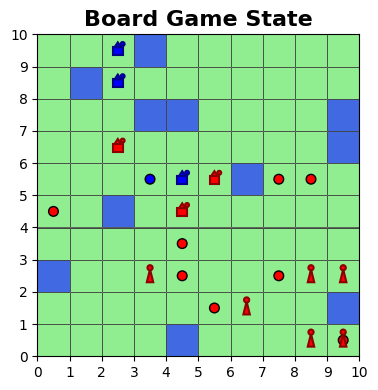

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(8), 'o_unit_index': np.int64(2)}


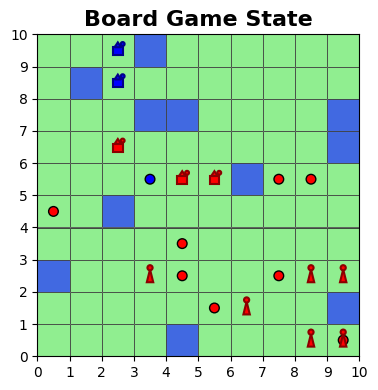

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(8), 'target_id': np.int64(36), 'path': [44, 35, 36]}


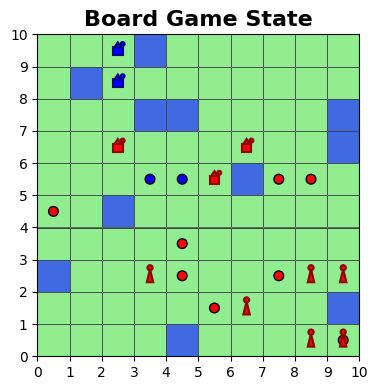

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(10), 'target_id': np.int64(97), 'path': [98, 97]}


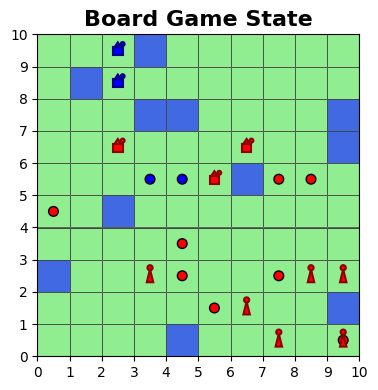

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(5), 'target_id': np.int64(21), 'path': [32, 21]}


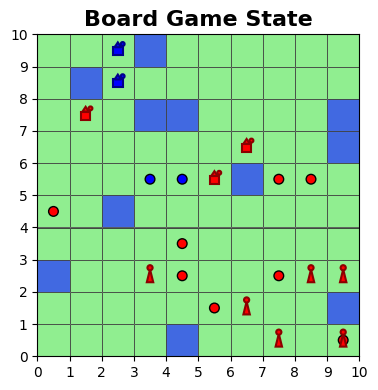

{'type': <ActionTypes.Attack: 1>, 'unit': np.int64(5), 'o_unit_index': np.int64(0)}


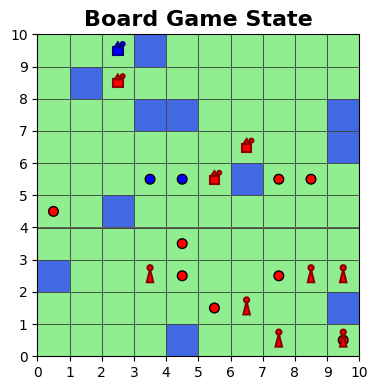

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(11), 'target_id': np.int64(88), 'path': [99, 88]}


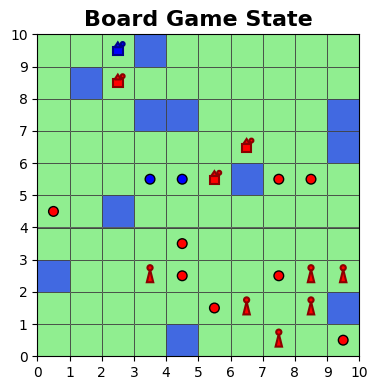

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(9), 'target_id': np.int64(69), 'path': [79, 69]}


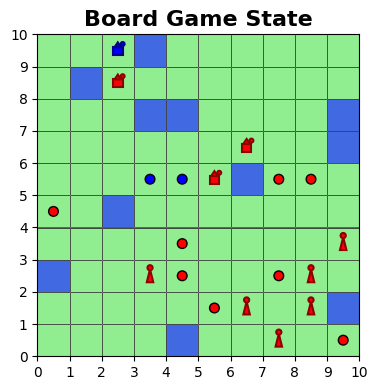

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(5), 'target_id': np.int64(32), 'path': [12, 22, 32]}


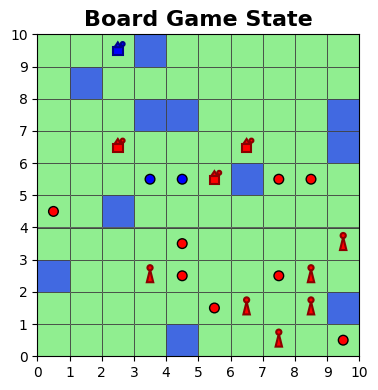

{'type': <ActionTypes.MoveUnit: 0>, 'unit': np.int64(3), 'target_id': np.int64(20), 'path': [31, 20]}


In [20]:
for i in range(50):

    #for unit in game2.players[game2.player_go_id].units_under_control:
    #    print(unit, "    ", unit.tile.id)

    render_board(game2.game_board.board_graph, board_config["board_size"][0], board_config["board_size"][0])
    
    action_mask = get_action_mask(game2)

    #print(action_mask)

    action = _create_random_action_from_action_mask(action_mask)

    action_dict = _translate_action(game2, action)

    print(action_dict)

    game2.apply_action(action_dict)

In [21]:
for unit in game2.players[game2.player_go_id].units_under_control:
    print(unit, "    ", unit.tile.id)

Warrior (3/10) in state ready      73
Warrior (10/10) in state ready      86
Warrior (3/10) in state ready      79
Warrior (2/10) in state idle      20
Rider (2/10) in state can_hit      45
Rider (5/10) in state idle      32
Warrior (7/10) in state ready      66
Warrior (10/10) in state ready      78
Rider (8/10) in state idle      36
Warrior (10/10) in state idle      69
Warrior (10/10) in state idle      97
Warrior (10/10) in state idle      88


In [22]:
city2 = game2.players[0].cities_under_control[0]